In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("..")

In [3]:
from IPython.display import clear_output
from src.dataset_loaders import load_vectors, get_samplers_paired, get_samplers
from src.utils import get_pca_models
from src import utils
from src.train import train_continuous
import wandb
from torch.utils.data import TensorDataset, DataLoader
import yaml
import numpy as np
import pickle
import random
import jax

## 1. Parameters.

Possible ```DATASET_NAME``` values are: ```twitter```, ```wiki-gigaword```, ```bone_marrow```

In [4]:
DATASET_NAME = 'twitter'

SOURCE_DIM   = 100  
TARGET_DIM   = 50

EMB_TYPE_SOURCE = 'glove'
EMB_TYPE_TARGET = 'glove'

#SOURCE_LANG     = 'en'
#TARGET_LANG     = 'fr'

#VS              = 200000

In [5]:
METHOD_NAME  = 'NeuralGW'
DEVICE       = 'cuda:0'

ALPHA_INIT    = 1.0
SEED_INIT     = 43
COST_DISCRETE = 'cosine'

config = {'dataset':dict(DATASET_NAME     = DATASET_NAME,
                         DEVICE           = DEVICE,
                         SOURCE_DIM       = SOURCE_DIM,
                         TARGET_DIM       = TARGET_DIM,
                         EMB_TYPE_SOURCE  = EMB_TYPE_SOURCE,
                         EMB_TYPE_TARGET  = EMB_TYPE_TARGET,
                         #SOURCE_LANG      = SOURCE_LANG,
                         #TARGET_LANG      = TARGET_LANG,
                         
                         #VS               = VS,
                         N_MAX_SAMPLES    = 400000, #set to 6667 to get N_train=3K
                         N_TRAIN_SAMPLES  = 380000, #We used 6000 for the others
                         N_TEST_SAMPLES   = 512,
                         N_EVAL           = 4,
                         ALPHA            = ALPHA_INIT, 
                         BATCH_SIZE_TRAIN = 500,
                         BATCH_SIZE_TEST  = 512,
                         SEED             = SEED_INIT,
                         NORMALIZE_VECS   = False,
                         SHUFFLE          = True
                          ),
          
          'training':dict(TRAIN_TYPE      = 'continuous',
                          METHOD_NAME     = METHOD_NAME,
                          N_EPOCHS        = 100,
                          COST_DISCRETE   = COST_DISCRETE,
                          ),

          #===============================CycleGW===============================
          #'model_specific':dict(HIDDEN_SIZES_MLP = [512]*1,
          #                      EPS              = 5e-4, #5e-3
          #                      F_LR             = 1e-3, #1e-3
          #                      G_LR             = 1e-3,#1e-3
          #                      REG              = 0.1,#0.1
          #                      SIGMAS           = None,
          #                      TAKE_MEDIAN      = True,
          #                      KERNEL_TYPE      = 'sinkhorn'
          #                     )  
          #===============================RegGW===============================
          #'model_specific':dict(HIDDEN_SIZES_MLP= [512, 256, 256],
          #                      EPS_FIT         = 0.01,
          #                      EPS_REG         = 0.001,
          #                      LAMBDA          = 1,
          #                      MOVER_LR        = 1e-4,)
#
          #===============================FlowGW===============================
          #'model_specific':dict(HIDDEN_SIZES_MLP = [1024, 1024, 1024, 1024],
          #                      EPS              = 1e-4,
          #                      N_FREQ           = 128,
          #                      MOVER_LR         = 1e-4)

          #===============================EntropicGW===============================
          #'model_specific':dict(COST_ITERS      = 1,
          #                      CRITIC_ITERS    = 1,
          #                      COST_LR         = 1e-4,
          #                      CRITIC_LR       = 1e-4,
          #                      HIDDEN_SIZES_MLP= [512, 512, 512, 512],
          #                      EPS             = 1e-3)
          
          #===============================NeuralGW===============================
          'model_specific':dict(COST_ITERS      = 1,
                                MOVER_ITERS     = 10,
                                CRITIC_ITERS    = 1,
                                REG_CRITIC      = 0.1,
                                COST_LR         = 1e-4,
                                MOVER_LR        = 1e-4, 
                                CRITIC_LR       = 1e-4,
                                HIDDEN_SIZES_MLP= [512, 512, 512, 512],)
          #===============================NeuralGW===============================
          #'model_specific':dict(MOVER_ITERS     = 10,
          #                      MOVER_LR        = 1e-4, 
          #                      HIDDEN_SIZES_MLP= [512, 512, 512, 512],
          #                      USE_P           = True)
           }



## 2. Loading dataset.

In [6]:
dataset_path = '../datasets'
sys.path.append(dataset_path)

source_vectors, target_vectors = load_vectors(dataset_path, config)

print(source_vectors.shape)
print(target_vectors.shape)

Loading twitter_glove_100 to source...
Loading twitter_glove_50 to target...
torch.Size([400000, 100])
torch.Size([400000, 50])


## 3. Training.

Source pairs...
190000
tensor([ 20212, 149990, 365022,  ...,  93642, 288493, 196469],
       dtype=torch.int32)
Target pairs...
190000
tensor([263080, 222873,  43855,  ..., 348179, 260404, 354886],
       dtype=torch.int32)
Experiment for ALPHA=1.0
Source pairs...
190000
tensor([ 20212, 149990, 365022,  ...,  13174,  23396, 350984],
       dtype=torch.int32)
Target pairs...
190000
tensor([ 20212, 149990, 365022,  ...,  13174,  23396, 350984],
       dtype=torch.int32)


2025-04-21 11:47:36.743247: W external/xla/xla/service/gpu/nvptx_compiler.cc:765] The NVIDIA driver's CUDA version is 12.3 which is older than the ptxas CUDA version (12.5.40). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Seed:  1374


wandb: Currently logged in as: xavier13091994 (entropic_gw). Use `wandb login --relogin` to force relogin


Epoch:   0%|          | 0/100 [00:00<?, ?it/s]

...

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/4 [00:00<?, ?it/s]

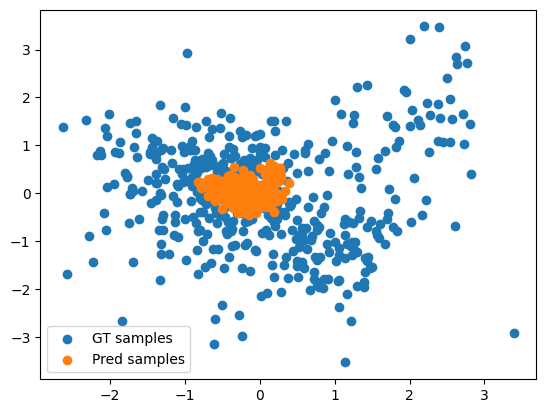

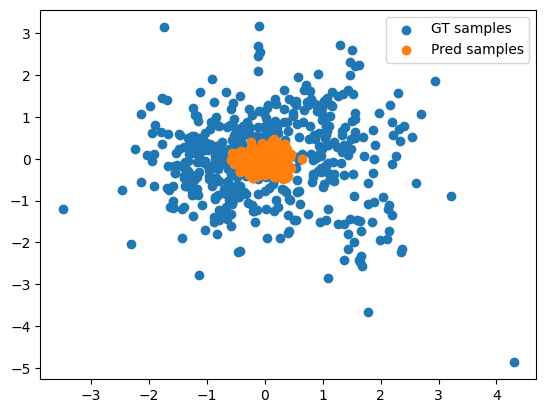

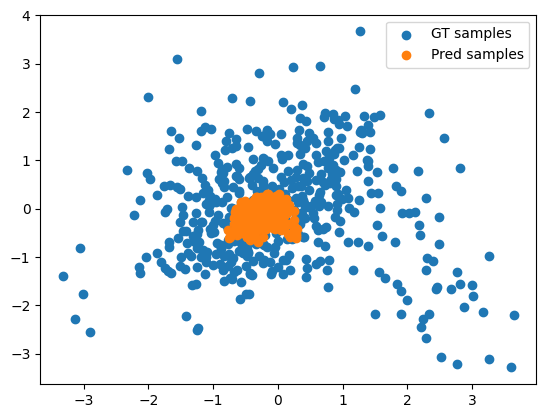

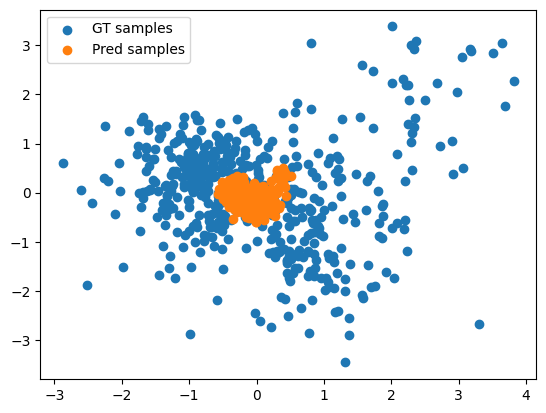

Evaluation:   0%|          | 0/4 [00:00<?, ?it/s]

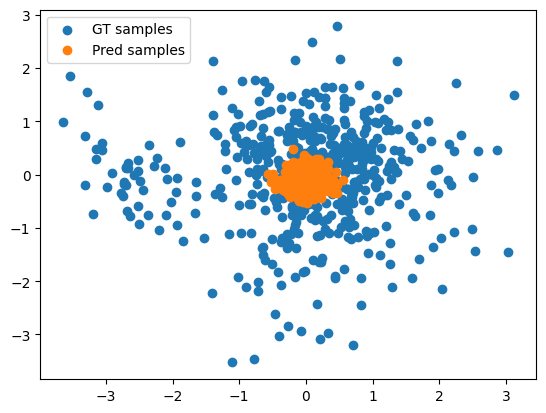

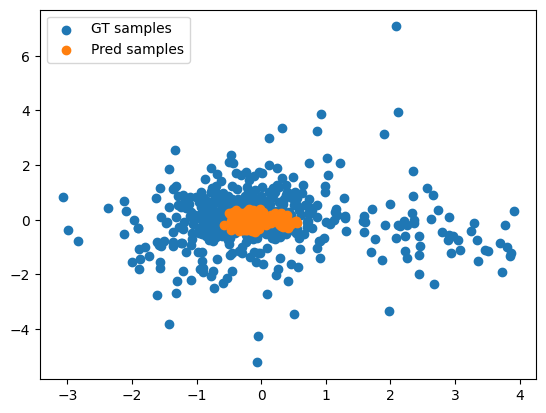

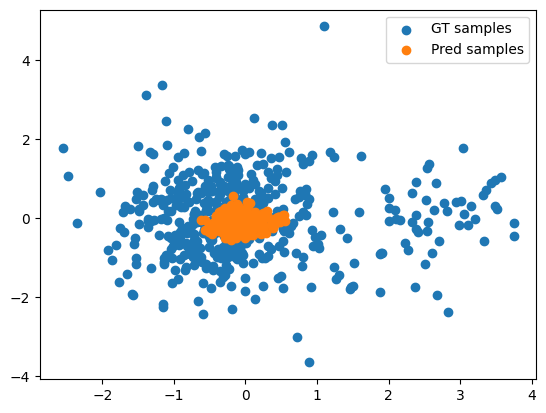

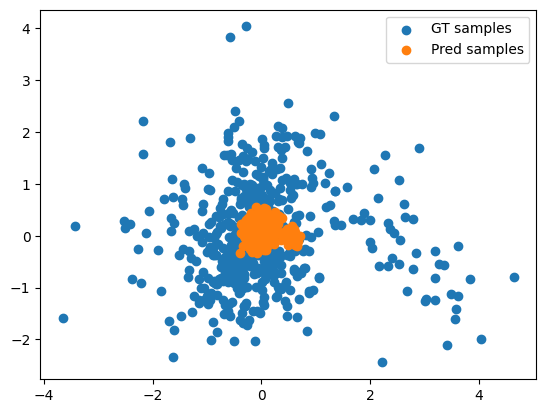

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

...

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/4 [00:00<?, ?it/s]

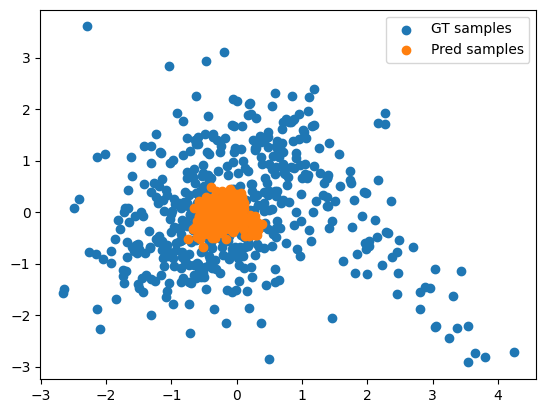

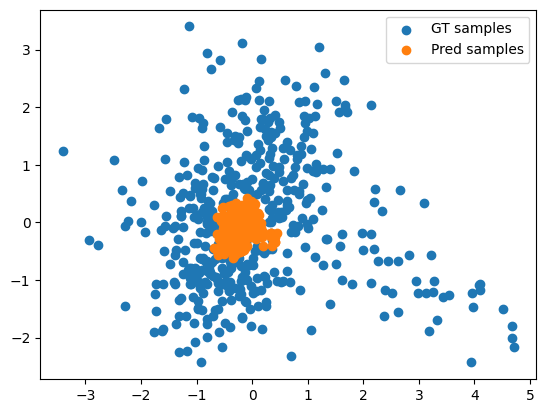

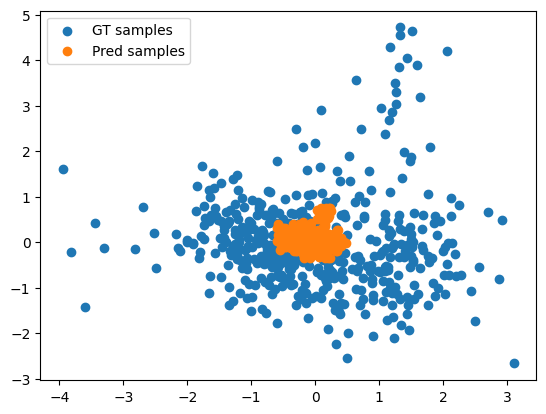

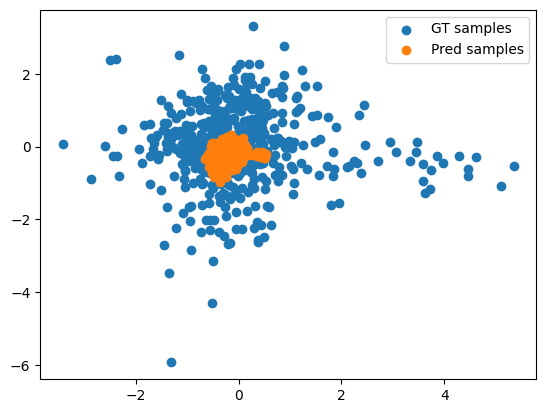

Evaluation:   0%|          | 0/4 [00:00<?, ?it/s]

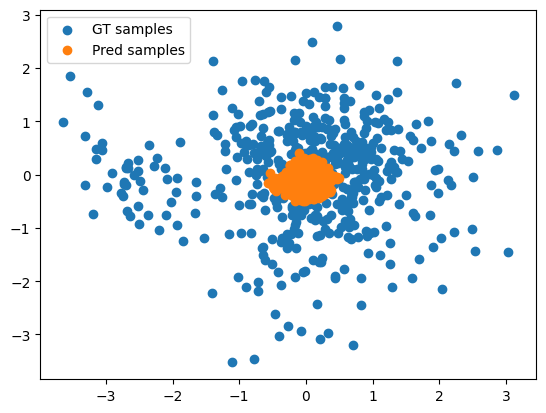

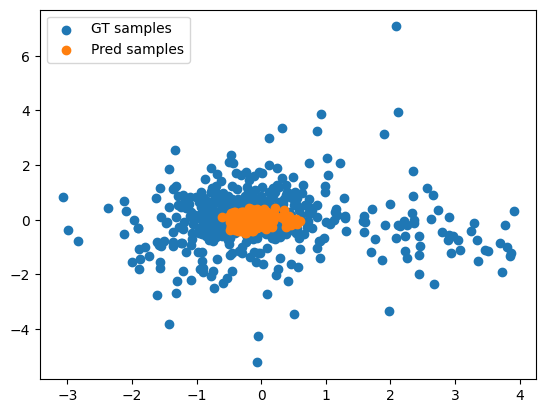

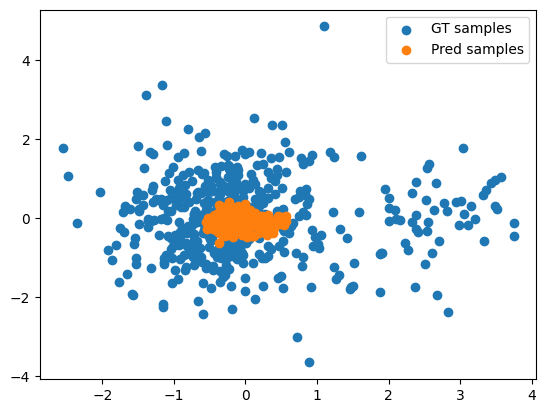

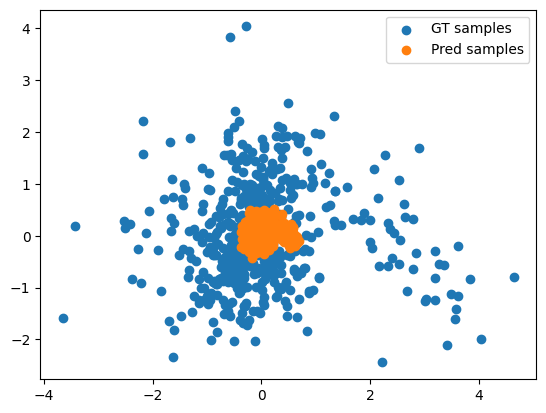

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

...

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/4 [00:00<?, ?it/s]

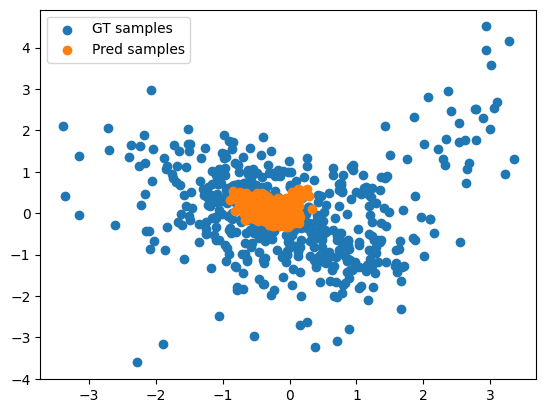

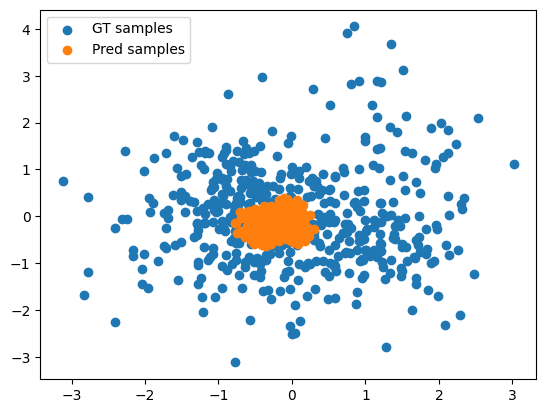

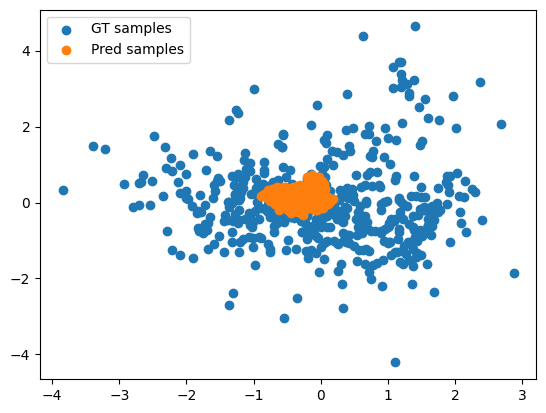

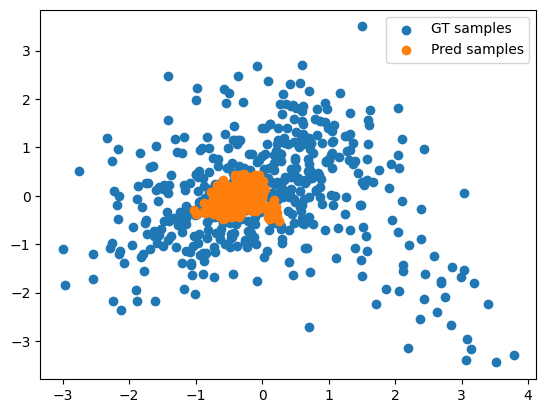

Evaluation:   0%|          | 0/4 [00:00<?, ?it/s]

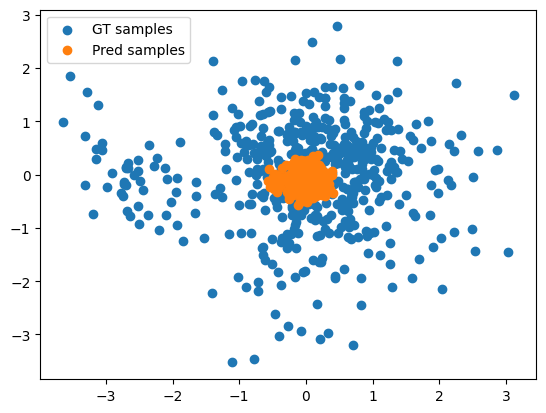

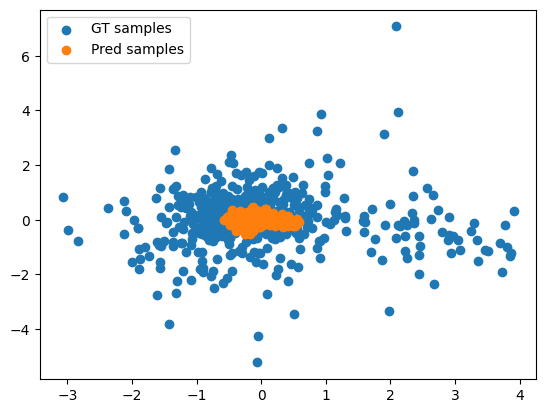

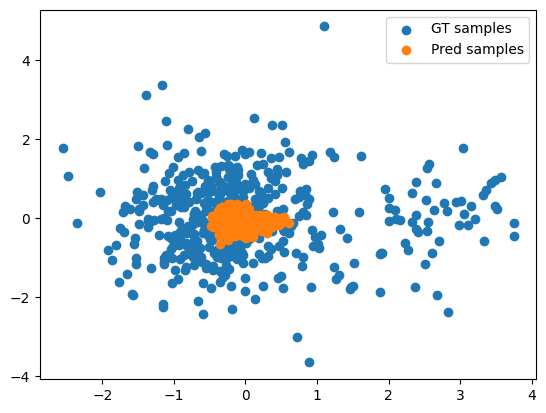

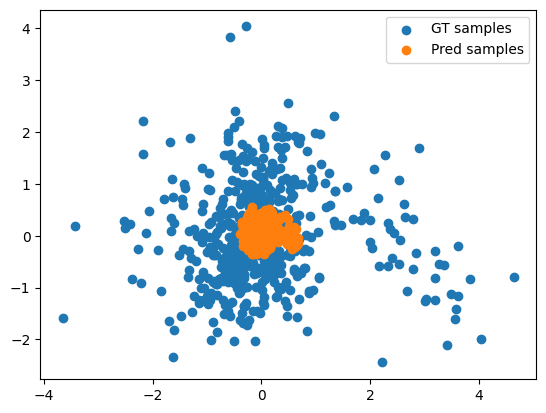

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

...

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/4 [00:00<?, ?it/s]

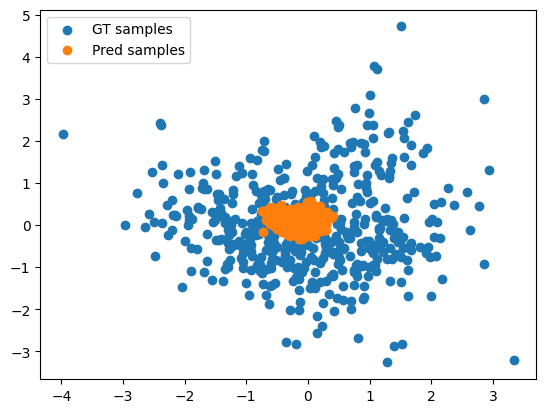

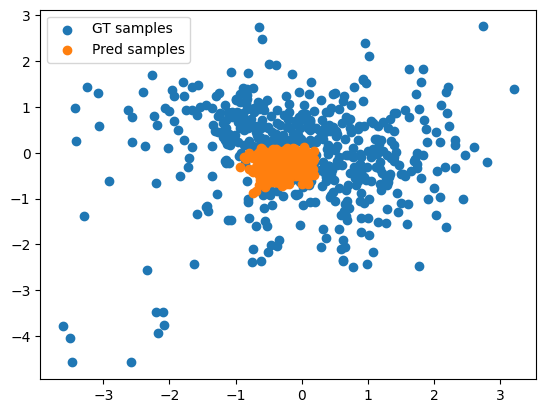

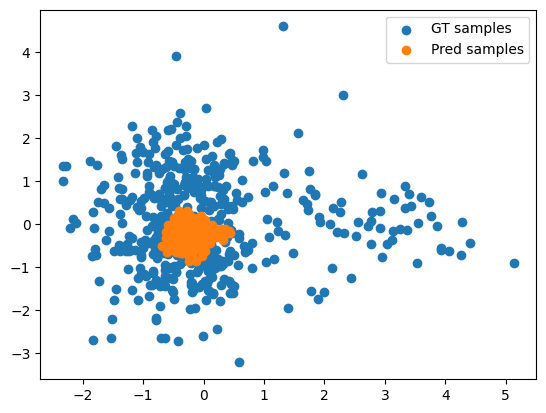

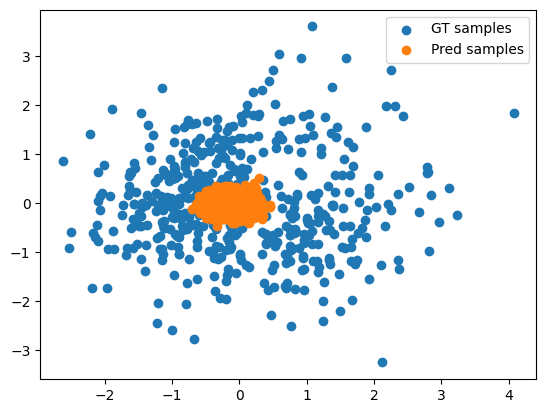

Evaluation:   0%|          | 0/4 [00:00<?, ?it/s]

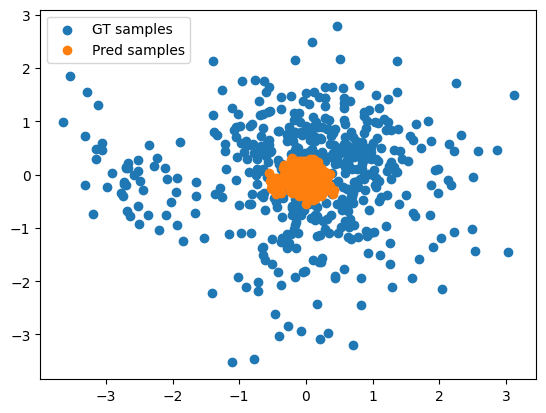

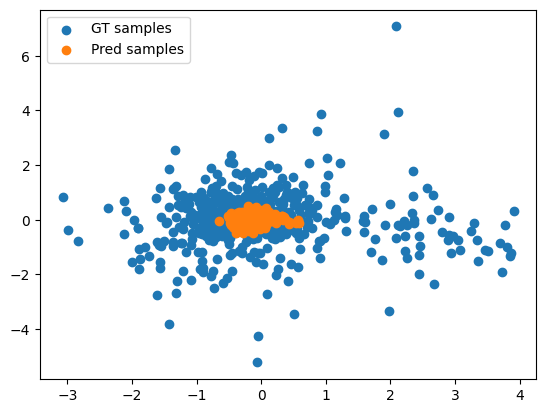

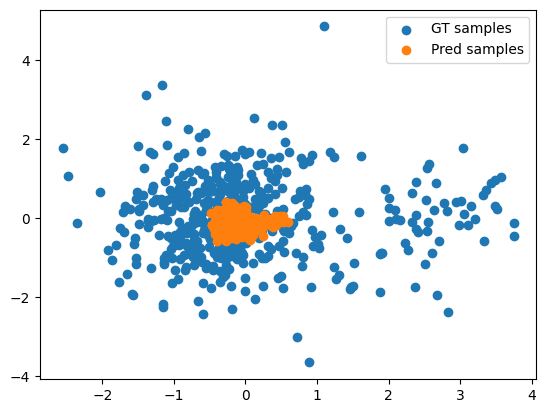

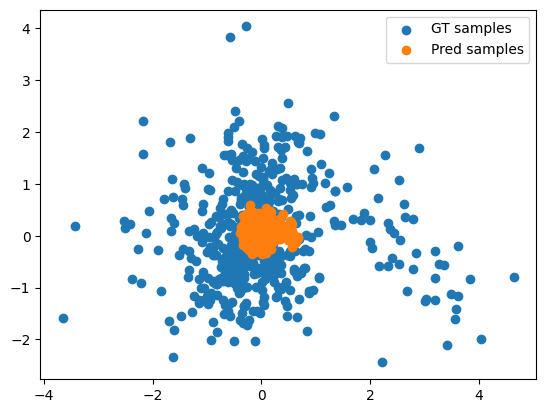

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

...

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Train:   0%|          | 0/380 [00:00<?, ?it/s]

Interrumpting by keyboard...
Seed:  6133


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x15554b5b92d0>>
Traceback (most recent call last):
  File "/trinity/home/xavier.aramayo/miniconda3/envs/jax/lib/python3.10/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 
wandb: ERROR Control-C detected -- Run data was not synced


KeyboardInterrupt: 

In [7]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

wandb_report = True

_, _, _, _, test_sampler = get_samplers_paired(config, source_vectors, target_vectors)

n_repeats    = 5
N            = config['dataset']['N_MAX_SAMPLES']//1000
TRAIN_TYPE   = config['training']['TRAIN_TYPE']
project_name = f'ICML_{METHOD_NAME}_{DATASET_NAME}_{SOURCE_DIM}({EMB_TYPE_SOURCE})->{TARGET_DIM}({EMB_TYPE_TARGET})_{N}K_{n_repeats}reps_metrics'
#project_name = f'{METHOD_NAME}_{DATASET_NAME}_{SOURCE_DIM}({SOURCE_LANG}_{EMB_TYPE_SOURCE})->{TARGET_DIM}({TARGET_LANG}_{EMB_TYPE_TARGET})_{N}K_{n_repeats}reps'

#metrics_names = ['Top@1', 'Top@5', 'Top@10', 'cossim_gt', 'inner_gw', 'foscttm']
metrics_names = ['Top@1', 'Top@5', 'Top@10', 'cossim_gt', 'inner_gw', 'foscttm', 'distortion', 'mmd', 'bw_uvp', 'sinkhorn_divergence']

shuffle = config['dataset']['SHUFFLE']
alpha_values = [0.0, 0.4, 0.7, 1.0][::-1]

metrics_out = {str(np.round(alpha, 1)):[] for alpha in alpha_values}

for ALPHA in alpha_values:
    
    config['dataset']['ALPHA'] = ALPHA 

        
    print('================================')
    print(f'Experiment for ALPHA={ALPHA}')
    print('================================')
    
    #source_vectors, target_vectors, train_source_sampler, train_target_sampler, _ = get_samplers_paired(config, source_vectors, target_vectors) 
    source_vectors, target_vectors, train_source_sampler, train_target_sampler, _ = get_samplers(config, source_vectors, target_vectors) 
    
    for ix in range(n_repeats):

        SEED = random.randint(0, 10000)
        rng = jax.random.PRNGKey(SEED)#utils.default_prng_key([number, number])
        config['dataset']['SEED'] = SEED
        print('Seed: ', SEED)
        
        if wandb_report:
            exp_name = f'ALPHA_{np.round(ALPHA, 1)}_repeat_{ix}_shuffled_{shuffle}'
            wandb.init(name=exp_name, config=config, project=project_name)
        
        #trained_class, metrics_dict = train_continuous(train_source_sampler, train_target_sampler,
        #                                               test_sampler, 
        #                                               metrics_names, target_vectors,
        #                                               config,
        #                                               wandb_report=wandb_report,
        #                                               axis_lims=None, report_every=5)

        trained_class, metrics_dict = train_continuous(train_source_sampler, train_target_sampler,
                                                       test_sampler, 
                                                       metrics_names, target_vectors,
                                                       config,
                                                       wandb_report=wandb_report,
                                                       axis_lims=None, report_every=10, source_vectors=source_vectors)
        
        metrics_out[str(np.round(ALPHA, 1))].append(metrics_dict)
    
        with open(f'results_{TRAIN_TYPE}_final/{project_name}_10_00.pkl', 'wb') as f:
            pickle.dump(metrics_out, f)